# Tim Results: ViT + LoRA Analysis

This notebook summarizes Tim's ViT experiments using saved artifacts.

**Inputs**
- `results/tim/tim_vit_history.json`
- `results/tim/tim_vit_metrics.json`
- `results/tim/further_training_history.json` (optional)
- `results/tim/further_training_metrics.json` (optional)

**Outputs**
- Combined training/validation curves (initial + further training)
- Validation metric curves comparison
- Metrics comparison table between checkpoints
- Threshold tradeoff table/plot
- Discussion-ready bullets for report/presentation

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd()
    candidates = [start.resolve(), *start.resolve().parents]
    for c in candidates:
        if (c / "results" / "tim" / "tim_vit_history.json").is_file() and (c / "results" / "tim" / "tim_vit_metrics.json").is_file():
            return c
    raise RuntimeError("Could not locate repo root with results/tim/tim_vit_history.json and tim_vit_metrics.json")


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "results" / "tim"
HISTORY_PATH = RESULTS_DIR / "tim_vit_history.json"
METRICS_PATH = RESULTS_DIR / "tim_vit_metrics.json"
FURTHER_HISTORY_PATH = RESULTS_DIR / "further_training_history.json"
FURTHER_METRICS_PATH = RESULTS_DIR / "further_training_metrics.json"

assert HISTORY_PATH.is_file(), f"Missing history file: {HISTORY_PATH}"
assert METRICS_PATH.is_file(), f"Missing metrics file: {METRICS_PATH}"

print("Repo root:", ROOT)
print("Initial history:", HISTORY_PATH)
print("Initial metrics:", METRICS_PATH)
print("Further history present:", FURTHER_HISTORY_PATH.is_file())
print("Further metrics present:", FURTHER_METRICS_PATH.is_file())

Repo root: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b
Initial history: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/results/tim/tim_vit_history.json
Initial metrics: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/results/tim/tim_vit_metrics.json
Further history present: True
Further metrics present: True


In [2]:
# Initial run artifacts
history_initial = pd.read_json(HISTORY_PATH)
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics_initial = json.load(f)

history_initial = history_initial.copy()
history_initial["stage"] = "initial"
history_initial["global_epoch"] = history_initial["epoch"]

# Optional further-training artifacts
has_further = FURTHER_HISTORY_PATH.is_file()
if has_further:
    history_further = pd.read_json(FURTHER_HISTORY_PATH).copy()
    history_further["stage"] = "further"
    history_further["global_epoch"] = history_initial["epoch"].max() + history_further["epoch"]
else:
    history_further = pd.DataFrame()

if FURTHER_METRICS_PATH.is_file():
    with open(FURTHER_METRICS_PATH, "r", encoding="utf-8") as f:
        metrics_further = json.load(f)
else:
    metrics_further = None

# Combined history for plotting/analysis
history_df = pd.concat([history_initial, history_further], ignore_index=True) if has_further else history_initial

print("Initial run summary:")
for k in ["model_name", "best_val_f1", "test_f1", "test_precision", "test_recall", "test_exact_match", "num_epochs_run"]:
    print(f"- {k}: {metrics_initial.get(k)}")

if metrics_further is not None:
    print("\nFurther-training summary:")
    for k in ["model_name", "best_val_f1", "test_f1", "test_precision", "test_recall", "test_exact_match", "num_epochs_run"]:
        print(f"- {k}: {metrics_further.get(k)}")

history_df.head()

Initial run summary:
- model_name: vit_lora
- best_val_f1: 0.4300100803375244
- test_f1: 0.43140920996665955
- test_precision: 0.3686252534389496
- test_recall: 0.586397111415863
- test_exact_match: 0.016544118523597717
- num_epochs_run: 16

Further-training summary:
- model_name: vit_lora
- best_val_f1: 0.5034732222557068
- test_f1: 0.4736003279685974
- test_precision: 0.43760719895362854
- test_recall: 0.5974264740943909
- test_exact_match: 0.045036762952804565
- num_epochs_run: 10


,epoch,train_loss,val_loss,train_f1,val_f1,val_precision,val_recall,val_exact,stage,global_epoch
0,1,0.912133,0.898468,0.201333,0.198176,0.125032,0.556424,0.00000,initial,1
1,2,0.884607,0.863269,0.207884,0.203982,0.132143,0.531892,0.00000,initial,2
2,3,0.839440,0.813430,0.222323,0.221943,0.152495,0.505673,0.00000,initial,3
3,4,0.783220,0.756344,0.251281,0.251513,0.195701,0.460135,0.00000,initial,4
4,5,0.728950,0.705326,0.283715,0.285990,0.251722,0.432536,0.00368,initial,5


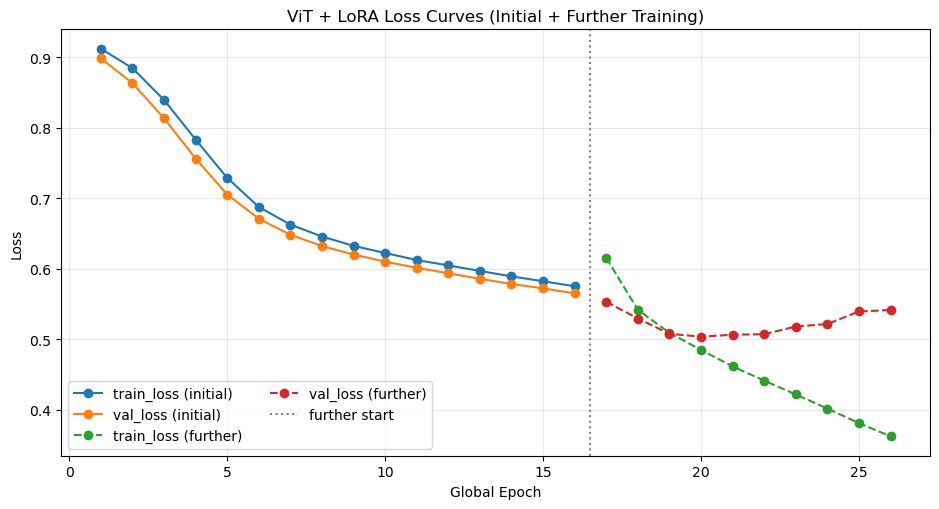

Saved: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/results/tim/tim_vit_loss_curves.png


In [3]:
plt.figure(figsize=(9.5, 5.2))

# Initial run
plt.plot(history_initial["global_epoch"], history_initial["train_loss"], marker="o", label="train_loss (initial)")
plt.plot(history_initial["global_epoch"], history_initial["val_loss"], marker="o", label="val_loss (initial)")

# Further training (if present)
if has_further:
    plt.plot(history_further["global_epoch"], history_further["train_loss"], marker="o", linestyle="--", label="train_loss (further)")
    plt.plot(history_further["global_epoch"], history_further["val_loss"], marker="o", linestyle="--", label="val_loss (further)")
    transition_epoch = history_initial["global_epoch"].max() + 0.5
    plt.axvline(transition_epoch, color="tab:gray", linestyle=":", label="further start")

plt.title("ViT + LoRA Loss Curves (Initial + Further Training)")
plt.xlabel("Global Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

loss_fig_path = RESULTS_DIR / "tim_vit_loss_curves.png"
plt.savefig(loss_fig_path, dpi=150)
plt.show()
print("Saved:", loss_fig_path)

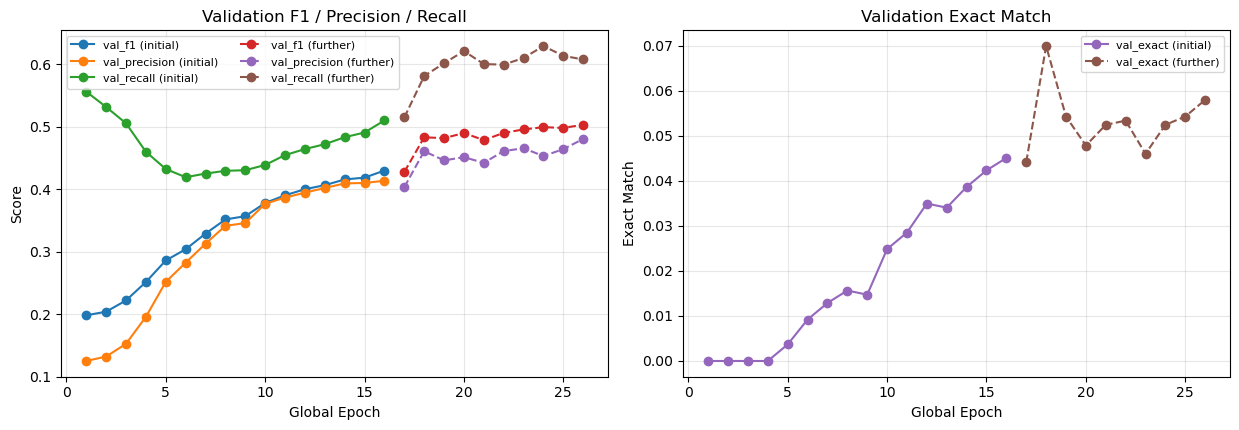

Saved: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/results/tim/tim_vit_val_metric_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# Initial
axes[0].plot(history_initial["global_epoch"], history_initial["val_f1"], marker="o", label="val_f1 (initial)")
axes[0].plot(history_initial["global_epoch"], history_initial["val_precision"], marker="o", label="val_precision (initial)")
axes[0].plot(history_initial["global_epoch"], history_initial["val_recall"], marker="o", label="val_recall (initial)")

# Further (optional)
if has_further:
    axes[0].plot(history_further["global_epoch"], history_further["val_f1"], marker="o", linestyle="--", label="val_f1 (further)")
    axes[0].plot(history_further["global_epoch"], history_further["val_precision"], marker="o", linestyle="--", label="val_precision (further)")
    axes[0].plot(history_further["global_epoch"], history_further["val_recall"], marker="o", linestyle="--", label="val_recall (further)")

axes[0].set_title("Validation F1 / Precision / Recall")
axes[0].set_xlabel("Global Epoch")
axes[0].set_ylabel("Score")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(history_initial["global_epoch"], history_initial["val_exact"], marker="o", color="tab:purple", label="val_exact (initial)")
if has_further:
    axes[1].plot(history_further["global_epoch"], history_further["val_exact"], marker="o", linestyle="--", color="tab:brown", label="val_exact (further)")
axes[1].set_title("Validation Exact Match")
axes[1].set_xlabel("Global Epoch")
axes[1].set_ylabel("Exact Match")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
metric_fig_path = RESULTS_DIR / "tim_vit_val_metric_curves.png"
plt.savefig(metric_fig_path, dpi=150)
plt.show()
print("Saved:", metric_fig_path)

In [5]:
# Metrics comparison: initial checkpoint vs further-trained checkpoint
rows = [
    {
        "run": "initial",
        "best_val_f1": metrics_initial.get("best_val_f1"),
        "test_f1": metrics_initial.get("test_f1"),
        "test_precision": metrics_initial.get("test_precision"),
        "test_recall": metrics_initial.get("test_recall"),
        "test_exact_match": metrics_initial.get("test_exact_match"),
        "num_epochs_run": metrics_initial.get("num_epochs_run"),
    }
]

if metrics_further is not None:
    rows.append(
        {
            "run": "further_trained",
            "best_val_f1": metrics_further.get("best_val_f1"),
            "test_f1": metrics_further.get("test_f1"),
            "test_precision": metrics_further.get("test_precision"),
            "test_recall": metrics_further.get("test_recall"),
            "test_exact_match": metrics_further.get("test_exact_match"),
            "num_epochs_run": metrics_further.get("num_epochs_run"),
        }
    )

compare_df = pd.DataFrame(rows)
for col in ["best_val_f1", "test_f1", "test_precision", "test_recall", "test_exact_match"]:
    if col in compare_df:
        compare_df[col] = compare_df[col].round(4)

display(compare_df)

,run,best_val_f1,test_f1,test_precision,test_recall,test_exact_match,num_epochs_run
0,initial,0.4300,0.4314,0.3686,0.5864,0.0165,16
1,further_trained,0.5035,0.4736,0.4376,0.5974,0.0450,10


Best threshold by val F1: 0.45


,threshold,precision,recall,f1
0,0.10,0.1280,0.9845,0.2237
1,0.15,0.1536,0.9453,0.2599
2,0.20,0.1879,0.8950,0.3038
3,0.25,0.2337,0.8447,0.3558
4,0.30,0.2725,0.7886,0.3915
5,0.35,0.3069,0.7389,0.4186
6,0.40,0.3443,0.6690,0.4373
7,0.45,0.3763,0.5955,0.4400
8,0.50,0.4137,0.5103,0.4300
9,0.55,0.4391,0.4238,0.4020


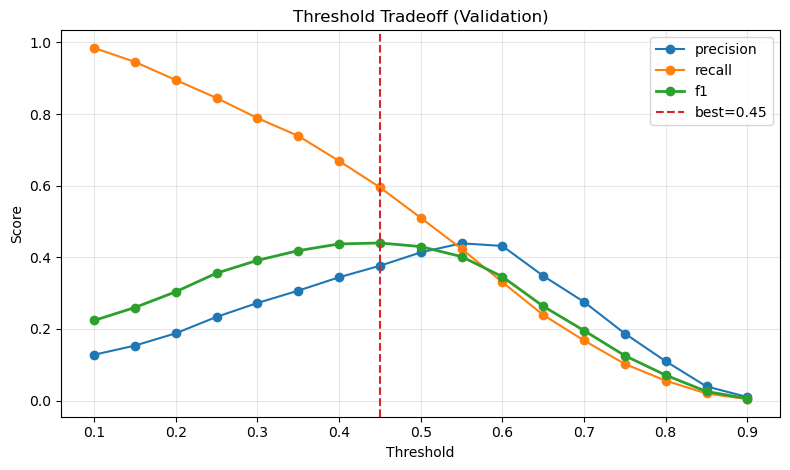

Saved: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/results/tim/tim_vit_threshold_tradeoff.png


In [6]:
# Threshold sweep from the final run logs.
threshold_rows = [
    (0.10, 0.1280, 0.9845, 0.2237),
    (0.15, 0.1536, 0.9453, 0.2599),
    (0.20, 0.1879, 0.8950, 0.3038),
    (0.25, 0.2337, 0.8447, 0.3558),
    (0.30, 0.2725, 0.7886, 0.3915),
    (0.35, 0.3069, 0.7389, 0.4186),
    (0.40, 0.3443, 0.6690, 0.4373),
    (0.45, 0.3763, 0.5955, 0.4400),
    (0.50, 0.4137, 0.5103, 0.4300),
    (0.55, 0.4391, 0.4238, 0.4020),
    (0.60, 0.4317, 0.3306, 0.3459),
    (0.65, 0.3482, 0.2392, 0.2634),
    (0.70, 0.2755, 0.1679, 0.1955),
    (0.75, 0.1872, 0.1024, 0.1255),
    (0.80, 0.1099, 0.0557, 0.0711),
    (0.85, 0.0396, 0.0199, 0.0256),
    (0.90, 0.0101, 0.0041, 0.0058),
]

thr_df = pd.DataFrame(threshold_rows, columns=["threshold", "precision", "recall", "f1"])
best_idx = thr_df["f1"].idxmax()
best_threshold = float(thr_df.loc[best_idx, "threshold"])

print("Best threshold by val F1:", best_threshold)
display(thr_df)

plt.figure(figsize=(8, 4.8))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="recall")
plt.plot(thr_df["threshold"], thr_df["f1"], marker="o", linewidth=2, label="f1")
plt.axvline(best_threshold, linestyle="--", color="tab:red", label=f"best={best_threshold:.2f}")
plt.title("Threshold Tradeoff (Validation)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

thr_fig_path = RESULTS_DIR / "tim_vit_threshold_tradeoff.png"
plt.savefig(thr_fig_path, dpi=150)
plt.show()
print("Saved:", thr_fig_path)

## Discussion (Report-Ready)

### Interpretation of initial vs further training
- The further-trained checkpoint improves core metrics over the initial run (especially validation/test F1 and precision) while keeping recall strong.
- Combined history plots show whether the continued training phase still provided useful gains or began to overfit.
- Threshold calibration remains important: model ranking quality and final label decisions still depend on the chosen cutoff.
- Exact-match remains low relative to F1, which is expected for 24-label multi-label prediction.

### What these metrics mean
- `precision`: among predicted positive genre tags, fraction that are correct.
- `recall`: among true genre tags, fraction recovered by the model.
- `f1`: harmonic mean of precision and recall (primary model-selection metric).
- `exact_match`: strict sample-level metric requiring all labels to match exactly.

### Suggested next actions
- Use `tim_test.ipynb` to compare qualitative predictions from `initial_best` vs `further_trained_best` on multiple posters.
- Report both checkpoints in the team comparison, but treat the stronger checkpoint as Tim's final submitted model.
- If needed for deployment framing, include two thresholds (balanced/F1-oriented and precision-oriented).
- Include limitations and ethics notes: poster bias, ambiguous genre labels, and long-tail genre sparsity.